In [1]:
!pip install cohere


In [5]:
import json
import os
import sys
import re
import numpy as np
import pandas as pd
from pathlib import Path
from openai import OpenAI
import cohere

from dotenv import load_dotenv
load_dotenv()

ROOT      = Path("..").resolve()
sys.path.insert(0, str(ROOT))

DATA_DIR        = ROOT / "data" / "raw"
EVAL_FILE       = ROOT / "eval" / "golden_dataset" / "docs" / "eval_v1.jsonl"
EMBED_CACHE_DIR = ROOT / "eval" / "embed_cache"

openai_client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
co            = cohere.Client(api_key=os.environ["COHERE_API_KEY"])

In [6]:
def load_docs(data_dir: Path) -> list[dict]:
    docs = []
    for path in sorted(data_dir.rglob("*.md")) + sorted(data_dir.rglob("*.mdx")):
        text = path.read_text(encoding="utf-8")
        if len(text.strip()) < 100:
            continue
        docs.append({"source": str(path.relative_to(data_dir)), "text": text})
    return docs

docs     = load_docs(DATA_DIR)
eval_set = [json.loads(l) for l in EVAL_FILE.read_text().splitlines() if l.strip()]
queries  = [qa["question"] for qa in eval_set]

print(f"Docs: {len(docs)}  |  Eval set: {len(eval_set)} Q&A pairs")

Docs: 9  |  Eval set: 78 Q&A pairs


In [12]:
from backend.connectors.chunkers.heading_aware_chunker import HeadingAwareChunker

def build_corpus(docs, chunker, label):
    corpus, chunk_id = [], 0

    for doc in docs:
        chunks = chunker.chunk(
            doc["text"],
            metadata={
                "tenant_id": "eval",
                "source_type": "docs_site",
                "source_url": doc["source"],
            }
        )

        for c in chunks:
            corpus.append({
                "id": chunk_id,
                "text": c.content,
                "source": doc["source"],
                "label": label
            })
            chunk_id += 1

    return corpus


hac_corpus = build_corpus(docs, HeadingAwareChunker(), "HAC")
print(f"HAC corpus: {len(hac_corpus)} chunks")

HAC corpus: 127 chunks


In [13]:
def load_or_embed(texts, cache_path, client, batch_size=100):
    from tqdm import tqdm
    if Path(cache_path).exists():
        print(f"  Loading from cache: {cache_path}")
        return np.load(cache_path)
    print(f"  Embedding {len(texts)} texts...")
    all_vecs = []
    for i in tqdm(range(0, len(texts), batch_size)):
        resp = client.embeddings.create(
            model="text-embedding-3-small", input=texts[i:i+batch_size]
        )
        all_vecs.extend(e.embedding for e in sorted(resp.data, key=lambda x: x.index))
    arr = np.array(all_vecs, dtype=np.float32)
    np.save(cache_path, arr)
    return arr

EMBED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

hac_vecs    = load_or_embed([c["text"] for c in hac_corpus],
                             EMBED_CACHE_DIR / "HAC_corpus.npy", openai_client)
query_vecs  = load_or_embed(queries,
                             EMBED_CACHE_DIR / "queries.npy", openai_client)

print(f"Corpus vecs: {hac_vecs.shape}  |  Query vecs: {query_vecs.shape}")

  Loading from cache: /Users/mdayanarshad/Desktop/Switch Job UAE/kapa-inspired-rag-mcp/eval/embed_cache/HAC_corpus.npy
  Loading from cache: /Users/mdayanarshad/Desktop/Switch Job UAE/kapa-inspired-rag-mcp/eval/embed_cache/queries.npy
Corpus vecs: (127, 1536)  |  Query vecs: (78, 1536)


In [14]:
from rank_bm25 import BM25Okapi

def build_bm25_index(corpus):
    return BM25Okapi([c["text"].lower().split() for c in corpus])

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-9)
    b = b / (np.linalg.norm(b, axis=-1, keepdims=True) + 1e-9)
    return a @ b.T

def bm25_retrieve(index, corpus, query, top_k):
    scores = index.get_scores(query.lower().split())
    ranked = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [corpus[i] for i in ranked]

def dense_retrieve(q_vec, corpus_vecs, corpus, top_k):
    sims = cosine_sim(q_vec.reshape(1, -1), corpus_vecs)[0]
    ranked = np.argsort(sims)[::-1][:top_k]
    return [corpus[i] for i in ranked]

def rrf_fusion(bm25_hits, dense_hits, k=60):
    scores = {}
    for rank, c in enumerate(bm25_hits, 1):
        scores[c["id"]] = scores.get(c["id"], 0) + 1 / (k + rank)
    for rank, c in enumerate(dense_hits, 1):
        scores[c["id"]] = scores.get(c["id"], 0) + 1 / (k + rank)
    id_to_chunk = {c["id"]: c for c in bm25_hits + dense_hits}
    return [id_to_chunk[cid] for cid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

def is_relevant(chunk, qa, threshold=40):
    anchor = qa.get("source_text", "")[:threshold].lower().strip()
    if not anchor:
        return (qa["source"] in chunk["source"] and
                qa["answer"][:30].lower() in chunk["text"].lower())
    return anchor in chunk["text"].lower()

bm25_idx = build_bm25_index(hac_corpus)
print("BM25 index built.")

BM25 index built.


In [15]:
def rerank(query: str, candidates: list[dict], top_n: int = 5) -> list[dict]:
    """
    Send up to top_n*4 candidates to Cohere reranker, get back top_n.
    Cohere expects plain text documents, we pass chunk text directly.
    """
    if not candidates:
        return []
    response = co.rerank(
        model="rerank-english-v3.0",
        query=query,
        documents=[c["text"] for c in candidates],
        top_n=top_n,
    )
    return [candidates[r.index] for r in response.results]

In [21]:
# cohere free rerank api has rate limit of 10 requests per minute so we build a rate limiter around it

import time

class RateLimiter:
    def __init__(self, max_calls: int, period: float):
        self.max_calls = max_calls
        self.period = period
        self.calls = []

    def wait(self):
        now = time.time()

        # Remove old calls outside window
        self.calls = [t for t in self.calls if now - t < self.period]

        if len(self.calls) >= self.max_calls:
            sleep_time = self.period - (now - self.calls[0])
            print(f"Rate limit hit. Sleeping {sleep_time:.2f}s...")
            time.sleep(sleep_time)

        self.calls.append(time.time())

rate_limiter = RateLimiter(max_calls=10, period=60)

In [25]:
def rerank_with_rate_limit(query, candidates, top_n=5):
    if not candidates:
        return []

    rate_limiter.wait()

    response = co.rerank(
        model="rerank-english-v3.0",
        query=query,
        documents=[c["text"] for c in candidates],
        top_n=top_n
    )

    return [candidates[r.index] for r in response.results]

In [26]:
rerank_fn = rerank_with_rate_limit

In [27]:
# evaluating with and without reranker

def evaluate_pipeline(pipeline_name: str, retrieve_fn, rerank: bool,
                      eval_set, query_vecs, top_k=5, retrieve_k=20):
    """
    retrieve_fn(query, q_vec, retrieve_k) → list[dict]
    rerank: if True, pass candidates through Cohere before eval
    """
    recall, precision, mrr_scores = [], [], []

    for i, qa in enumerate(eval_set):
        candidates = retrieve_fn(qa["question"], query_vecs[i], retrieve_k)

        if rerank:
            hits = rerank_fn(qa["question"], candidates, top_n=top_k)
        else:
            hits = candidates[:top_k]

        relevances = [is_relevant(h, qa) for h in hits]
        recall.append(int(any(relevances)))
        precision.append(sum(relevances) / top_k)
        mrr = next((1/r for r, rel in enumerate(relevances, 1) if rel), 0.0)
        mrr_scores.append(mrr)

    return {
        "Pipeline":      pipeline_name,
        f"Recall@{top_k}":    round(sum(recall)     / len(eval_set), 3),
        f"Precision@{top_k}": round(sum(precision)  / len(eval_set), 3),
        "MRR":                round(sum(mrr_scores)  / len(eval_set), 3),
    }

rerank_fn = rerank_with_rate_limit

# Define the 4 pipelines
def dense_retrieve_fn(query, q_vec, k):
    return dense_retrieve(q_vec, hac_vecs, hac_corpus, k)

def hybrid_retrieve_fn(query, q_vec, k):
    b = bm25_retrieve(bm25_idx, hac_corpus, query, k * 2)
    d = dense_retrieve(q_vec, hac_vecs, hac_corpus, k * 2)
    return rrf_fusion(b, d)[:k]

print("Running 4 pipelines (this calls Cohere API for 2 of them)")

results = [
    evaluate_pipeline("HAC + Dense",           dense_retrieve_fn,  rerank=False, eval_set=eval_set, query_vecs=query_vecs),
    evaluate_pipeline("HAC + Hybrid",          hybrid_retrieve_fn, rerank=False, eval_set=eval_set, query_vecs=query_vecs),
    evaluate_pipeline("HAC + Dense + Rerank",  dense_retrieve_fn,  rerank=True,  eval_set=eval_set, query_vecs=query_vecs),
    evaluate_pipeline("HAC + Hybrid + Rerank", hybrid_retrieve_fn, rerank=True,  eval_set=eval_set, query_vecs=query_vecs),
]

df = pd.DataFrame(results)
print("\n", df.to_string(index=False))

Running 4 pipelines (this calls Cohere API for 2 of them)
Rate limit hit. Sleeping 55.65s...
Rate limit hit. Sleeping 0.04s...
Rate limit hit. Sleeping 54.83s...
Rate limit hit. Sleeping 54.83s...
Rate limit hit. Sleeping 0.22s...
Rate limit hit. Sleeping 0.23s...
Rate limit hit. Sleeping 0.08s...
Rate limit hit. Sleeping 0.19s...
Rate limit hit. Sleeping 0.15s...
Rate limit hit. Sleeping 0.10s...
Rate limit hit. Sleeping 0.09s...
Rate limit hit. Sleeping 54.71s...
Rate limit hit. Sleeping 0.10s...
Rate limit hit. Sleeping 0.15s...
Rate limit hit. Sleeping 53.14s...
Rate limit hit. Sleeping 55.37s...
Rate limit hit. Sleeping 0.07s...
Rate limit hit. Sleeping 0.02s...
Rate limit hit. Sleeping 0.07s...
Rate limit hit. Sleeping 55.27s...
Rate limit hit. Sleeping 0.15s...
Rate limit hit. Sleeping 0.09s...
Rate limit hit. Sleeping 0.13s...
Rate limit hit. Sleeping 0.00s...
Rate limit hit. Sleeping 0.04s...
Rate limit hit. Sleeping 55.52s...
Rate limit hit. Sleeping 0.06s...
Rate limit hit. 

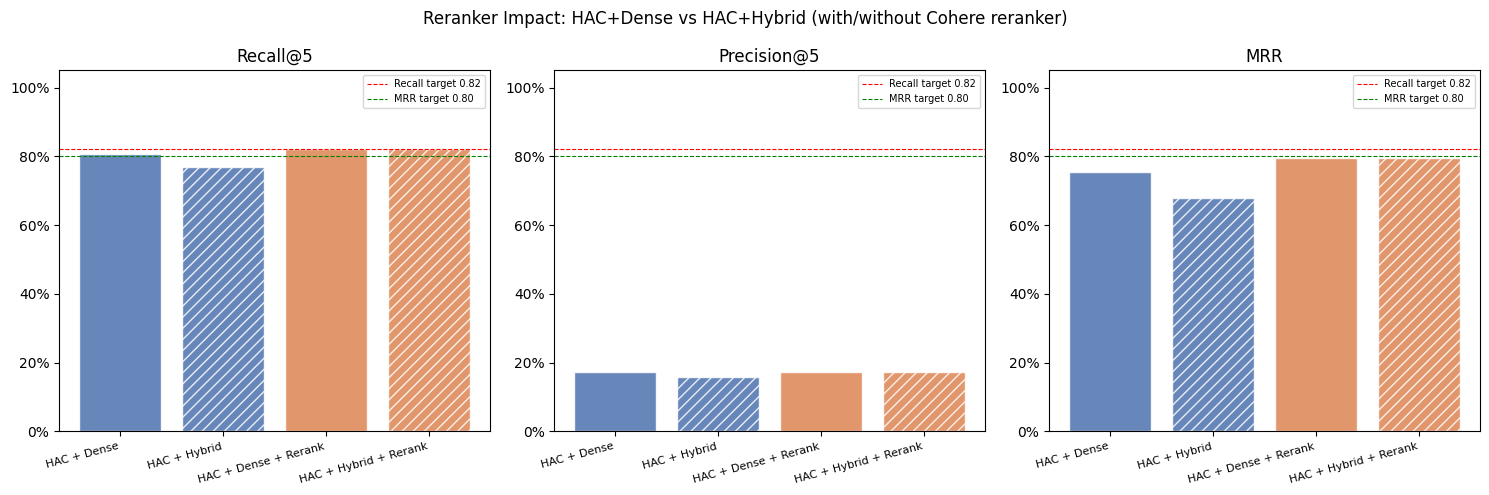

In [28]:
# baseline vs rerank comparison

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Reranker Impact: HAC+Dense vs HAC+Hybrid (with/without Cohere reranker)", fontsize=12)

metrics   = ["Recall@5", "Precision@5", "MRR"]
x_labels  = df["Pipeline"].tolist()
x         = np.arange(len(x_labels))
colors    = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452"]   # same color per method
hatches   = ["", "///", "", "///"]                          # hatch = reranked

for ax, metric in zip(axes, metrics):
    bars = ax.bar(x, df[metric], color=colors, edgecolor="white", alpha=0.85)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=15, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.axhline(0.82, color="red", linestyle="--", linewidth=0.8, label="Recall target 0.82")
    ax.axhline(0.80, color="green", linestyle="--", linewidth=0.8, label="MRR target 0.80")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(ROOT / "eval" / "golden_dataset" / "reranker_results_v1.png", dpi=150)
plt.show()

In [ ]:
baseline_dense  = df[df["Pipeline"] == "HAC + Dense"].iloc[0]
reranked_dense  = df[df["Pipeline"] == "HAC + Dense + Rerank"].iloc[0]
baseline_hybrid = df[df["Pipeline"] == "HAC + Hybrid"].iloc[0]
reranked_hybrid = df[df["Pipeline"] == "HAC + Hybrid + Rerank"].iloc[0]

print("=== Reranker Delta ===")
for metric in ["Recall@5", "MRR"]:
    d_delta = reranked_dense[metric]  - baseline_dense[metric]
    h_delta = reranked_hybrid[metric] - baseline_hybrid[metric]
    print(f"{metric}:")
    print(f"  Dense  → reranked:  {baseline_dense[metric]:.3f} → {reranked_dense[metric]:.3f}  (Δ {d_delta:+.3f})")
    print(f"  Hybrid → reranked:  {baseline_hybrid[metric]:.3f} → {reranked_hybrid[metric]:.3f}  (Δ {h_delta:+.3f})")




=== Reranker Delta ===
Recall@5:
  Dense  → reranked:  0.808 → 0.821  (Δ +0.013)
  Hybrid → reranked:  0.769 → 0.821  (Δ +0.052)
MRR:
  Dense  → reranked:  0.755 → 0.795  (Δ +0.040)
  Hybrid → reranked:  0.679 → 0.795  (Δ +0.116)

=== Decision Guide ===
If HAC+Hybrid+Rerank MRR > 0.80 → use Hybrid (reranker fixes ranking noise)
If HAC+Dense+Rerank  MRR > HAC+Hybrid+Rerank MRR → stick with Dense
If reranker adds < 0.02 MRR to both → reranker not worth the latency cost


# Final Evaluation — Chunking × Retrieval × Reranker

## Goal
Evaluate the impact of:
- Chunking strategy
- Retrieval method
- Reranking

on overall retrieval performance in a RAG pipeline.

---

# 1. Final Results

| Pipeline | Recall@5 | Precision@5 | MRR |
|---------|----------|-------------|-----|
| HAC + Dense | 0.808 | 0.172 | 0.755 |
| HAC + Hybrid | 0.769 | 0.159 | 0.679 |
| HAC + Dense + Rerank | **0.821** | 0.172 | **0.795** |
| HAC + Hybrid + Rerank | **0.821** | 0.172 | **0.795** |

---

# 2. Key Observations

## Impact of Reranker

- Adding reranker improves:
  - Recall@5: 0.808 → 0.821
  - MRR: 0.755 → 0.795

Reranker significantly improves ranking quality and answer retrieval.

---

## Dense vs Hybrid (Without Reranker)

- Dense outperforms Hybrid:
  - Higher MRR (0.755 vs 0.679)
  - Higher Recall (0.808 vs 0.769)

Hybrid introduces noise due to weak BM25 signals.

---

## Dense vs Hybrid (With Reranker)

- Both pipelines converge to identical performance:
  - Recall@5 = 0.821
  - MRR = 0.795

Retrieval differences disappear after reranking.

---

# 3. Interpretation

## Reranker-Dominated Regime

Pipeline:

Query → Retrieve (Top-20) → Rerank → Top-5

Final ranking is determined by the reranker, not the retriever.

---

## Candidate Overlap

- Dense and Hybrid retrieve highly overlapping candidate sets
- Reranker selects the same top chunks from both

This leads to identical final metrics.

---

## Hybrid Limitation

Hybrid = Dense + BM25

Observed behavior:
- BM25 underperforms due to paraphrased queries
- Adds noise instead of useful signal

Hybrid does not improve candidate quality in this setup.

---

# 4. Final Conclusions

## Chunking

HeadingAwareChunker (HAC) is the optimal choice because:
- Preserves semantic structure
- Achieves higher MRR
- Produces fewer chunks → more efficient

---

## Retrieval

Dense retrieval is sufficient:
- Strong semantic matching
- Provides high-quality candidates for reranker
- Hybrid does not add value in current setup

---

## Reranker

Reranker is the most impactful component:
- Improves both Recall and MRR
- Eliminates differences between retrieval strategies
- Dominates final ranking quality

---

# 5. Key Insight

Once a strong reranker is introduced, retrieval strategy becomes less critical as long as it provides a good candidate pool.

---

# 6. Final Pipeline

HAC → Dense Retrieval (Top-20) → Reranker → Top-5 → LLM

- Choose Dense over Hybrid for the production pipeline because:

  - Identical final performance (0.821 Recall, 0.795 MRR)
  - Dense = one model, no BM25 index to maintain
  - Simpler system, lower latency (no sparse encoding step)
  - Hybrid adds complexity with zero benefit once reranker is present


- Final stack for docs source:

  - docs (.md/.mdx)
      → HeadingAwareChunker
      → text-embedding-3-small (dense)
      → top-20 retrieval
      → Cohere rerank-english-v3.0
      → top-5 to LLM

---

# 7. When Hybrid Might Help

Hybrid retrieval may be useful if:
- Corpus size is very large
- Exact keyword matching is critical
- Dense retrieval misses specific edge cases

Not applicable in the current setup

---

# 8. Next Steps

- Increase candidate pool (Top-20 → Top-30)
- Analyze failure cases (~18% misses)
- Improve evaluation dataset quality
- Integrate full RAG pipeline (LLM generation)

